# Notebook Tour

This notebook exists so the `.ipynb` reader has something real to render.
Open it with `python3 tome.py` and check each cell below against what this
one says should happen.

A notebook is JSON, so nothing here is *parsed* — the cells are handed to the
same two pieces of machinery every other doc uses. Markdown cells go to the
markdown renderer, code cells to the syntax highlighter.


## Markdown cells are ordinary docs

Everything the markdown renderer does works in a markdown cell: **bold**,
*italic*, `inline code`, [links to other docs](../README.md), and links to
[source files](../tome.py) that open highlighted in the reader.

| what          | where it goes                        |
|---------------|--------------------------------------|
| markdown cell | the markdown renderer                |
| code cell     | the syntax highlighter               |
| outputs       | below the cell that produced them    |

> [!NOTE]
> The table of contents on the right is built across *all* the markdown
> cells at once, not per cell — every `##` below is in it.


## Code cells and stdout

The language comes off the notebook's kernel metadata, so the highlighter
knows this is Python without being told per cell.


In [1]:
from dataclasses import dataclass


@dataclass
class TokenBucket:
    capacity: int = 10
    rate: float = 5.0     # tokens per second
    tokens: float = 10.0

    def take(self, n: int = 1) -> bool:
        if self.tokens >= n:
            self.tokens -= n
            return True
        return False


bucket = TokenBucket()
for i in range(4):
    print(f"request {i}: {'ok' if bucket.take(3) else 'REJECTED'}")


request 0: ok
request 1: ok
request 2: ok
request 3: REJECTED


## Execution results

A cell's last expression comes back as `text/plain`, and renders the same way
stdout does — quieter than the code, attached to the cell that produced it.


In [2]:
bucket


TokenBucket(capacity=10, rate=5.0, tokens=1.0)

## Plots

A PNG output is embedded as a `data:` URI, so it needs no network and no
`/raw` round trip. Matplotlib writes PNGs with a transparent background, which
would be invisible on every one of tome's dark themes — so plots get a white
plate underneath. **This plot is deliberately transparent: if you can see the
axes on a dark theme, the plate is working.**


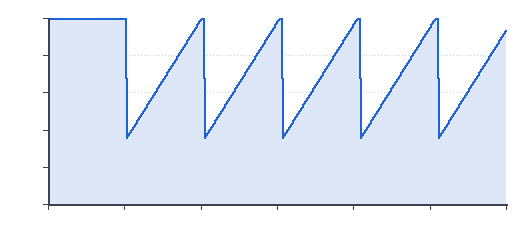

In [3]:
import matplotlib.pyplot as plt

tokens, series = 10.0, []
for t in range(470):
    tokens = min(10.0, tokens + 0.086)
    if t and t % 78 == 0:
        tokens = max(0.0, tokens - 6.4)
    series.append(tokens)

plt.plot(series)
plt.show()


## Tracebacks

Jupyter stores a traceback with its terminal colour codes still in it. Those
are stripped — an escape sequence rendered literally is noise, and the reader
has no terminal to interpret it.


In [4]:
TokenBucket(capacity=-1).take(1)


ValueError: capacity must be positive, got -1

## Long output

Output is capped, because a cell that printed a thousand log lines should not
turn the page into that log. The cap is `NB_OUTPUT_LIMIT` in `tome.py`.


In [5]:
for i in range(400):
    print(f'{i:04d} refill tick, tokens={i % 11}')


0000 refill tick, tokens=0
0001 refill tick, tokens=1
0002 refill tick, tokens=2
0003 refill tick, tokens=3
0004 refill tick, tokens=4
0005 refill tick, tokens=5
0006 refill tick, tokens=6
0007 refill tick, tokens=7
0008 refill tick, tokens=8
0009 refill tick, tokens=9
0010 refill tick, tokens=10
0011 refill tick, tokens=0
0012 refill tick, tokens=1
0013 refill tick, tokens=2
0014 refill tick, tokens=3
0015 refill tick, tokens=4
0016 refill tick, tokens=5
0017 refill tick, tokens=6
0018 refill tick, tokens=7
0019 refill tick, tokens=8
0020 refill tick, tokens=9
0021 refill tick, tokens=10
0022 refill tick, tokens=0
0023 refill tick, tokens=1
0024 refill tick, tokens=2
0025 refill tick, tokens=3
0026 refill tick, tokens=4
0027 refill tick, tokens=5
0028 refill tick, tokens=6
0029 refill tick, tokens=7
0030 refill tick, tokens=8
0031 refill tick, tokens=9
0032 refill tick, tokens=10
0033 refill tick, tokens=0
0034 refill tick, tokens=1
0035 refill tick, tokens=2
0036 refill tick, tokens=

## What is skipped

An output richer than text or a PNG is left out rather than guessed at.
`text/html` and `image/svg+xml` in particular carry arbitrary markup, and
injecting that into the reader would break the page's styling at best.

Raw cells — the one below this — are skipped for the same reason: they exist
to be passed through to a specific export format, and this is not one.
